# Introduction & Problem Statement

This project analyzes employee data to understand the key factors influencing promotions within an organization. The dataset includes information such as demographics, training performance, experience, and departmental attributes.

The objective of this analysis is to identify patterns and relationships that impact promotion decisions. By uncovering these insights, the study aims to help organizations improve employee evaluation and ensure fair, performance-driven promotion strategies.

## Libraries

In [194]:
# imporing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sma
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

## Data Loading, Cleaning & Understanding

In [195]:
# loading data
data = pd.read_csv(r'train.csv')

In [196]:
data.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


In [197]:
data.shape

(54808, 13)

In [198]:
data.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'awards_won?', 'avg_training_score',
       'is_promoted'],
      dtype='object')

In [199]:
# removing duplicates
data = data.drop_duplicates(subset=['employee_id'])
data.shape

(54808, 13)

In [200]:
data.isnull().sum()

employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

In [201]:
# since education is a categorical column thus checking the data with mode
data['education'].mode()

0    Bachelor's
Name: education, dtype: object

In [202]:
# since the mode is bachelor's thus assuming the null value to be bachelor's
data['education'].fillna(data['education'].mode()[0], inplace=True)

In [203]:
# assuming employees did not fill previous_year_rating thus making it 0
data['previous_year_rating'].fillna(0, inplace=True)

In [204]:
data.isnull().sum()

employee_id             0
department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
awards_won?             0
avg_training_score      0
is_promoted             0
dtype: int64

In [205]:
data.set_index('employee_id', inplace=True)

In [206]:
data.head()

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
employee_id,,,,,,,,,,,,
65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


In [207]:
data.columns

Index(['department', 'region', 'education', 'gender', 'recruitment_channel',
       'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service',
       'awards_won?', 'avg_training_score', 'is_promoted'],
      dtype='object')

In [208]:
# seperating colums into categorical and numerical
cat_cols = ['department', 'region', 'education', 'gender', 'recruitment_channel', 'no_of_trainings', 'previous_year_rating','awards_won?']
num_cols = [col for col in data.columns if col not in cat_cols]

In [209]:
print(cat_cols)

['department', 'region', 'education', 'gender', 'recruitment_channel', 'no_of_trainings', 'previous_year_rating', 'awards_won?']


In [210]:
print(num_cols)

['age', 'length_of_service', 'avg_training_score', 'is_promoted']


In [211]:
# distribution in cat_cols
for i in cat_cols:
    print(f' distribution in {i}:\n{data[i].value_counts(normalize=True).round(2)}\n')

 distribution in department:
department
Sales & Marketing    0.31
Operations           0.21
Technology           0.13
Procurement          0.13
Analytics            0.10
Finance              0.05
HR                   0.04
Legal                0.02
R&D                  0.02
Name: proportion, dtype: float64

 distribution in region:
region
region_2     0.23
region_22    0.12
region_7     0.09
region_15    0.05
region_13    0.05
region_26    0.04
region_31    0.04
region_4     0.03
region_27    0.03
region_16    0.03
region_28    0.02
region_11    0.02
region_23    0.02
region_29    0.02
region_32    0.02
region_19    0.02
region_20    0.02
region_14    0.02
region_25    0.01
region_17    0.01
region_5     0.01
region_6     0.01
region_30    0.01
region_8     0.01
region_10    0.01
region_1     0.01
region_24    0.01
region_12    0.01
region_9     0.01
region_21    0.01
region_3     0.01
region_34    0.01
region_33    0.00
region_18    0.00
Name: proportion, dtype: float64

 distribution 

In [212]:
data[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,54808.0,34.80,7.66,20.0,29.0,33.0,39.0,60.0
length_of_service,54808.0,5.87,4.27,1.0,3.0,5.0,7.0,37.0
avg_training_score,54808.0,63.39,13.37,39.0,51.0,60.0,76.0,99.0
is_promoted,54808.0,0.09,0.28,0.0,0.0,0.0,0.0,1.0


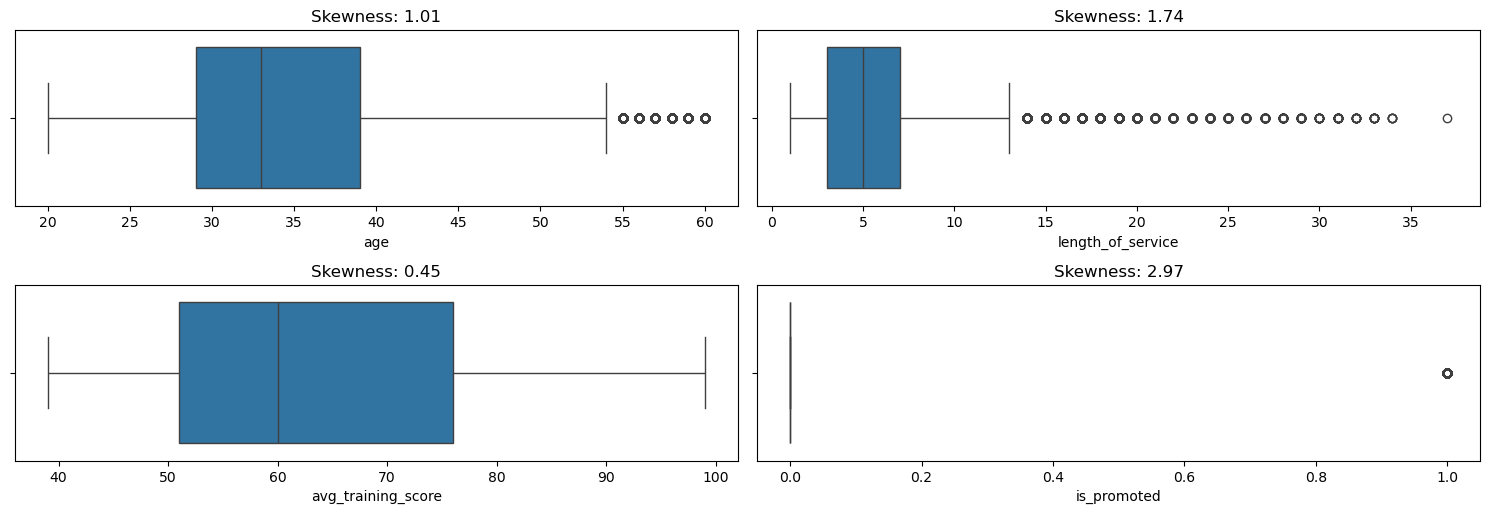

In [213]:
t=1
plt.figure(figsize=(15,15))
for i in num_cols:
    plt.subplot(6,2,t)
    plt.title(f'Skewness: {round(data[i].skew(),2)}')
    sns.boxplot(data=data,x=i)
    t+=1
plt.tight_layout()
plt.show()

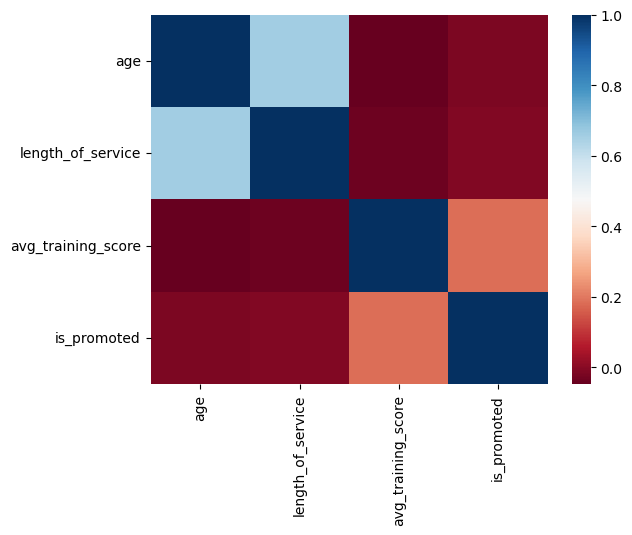

In [214]:
sns.heatmap(data[num_cols].corr(),cmap='RdBu')
plt.show()

## Data Analysis & visualization

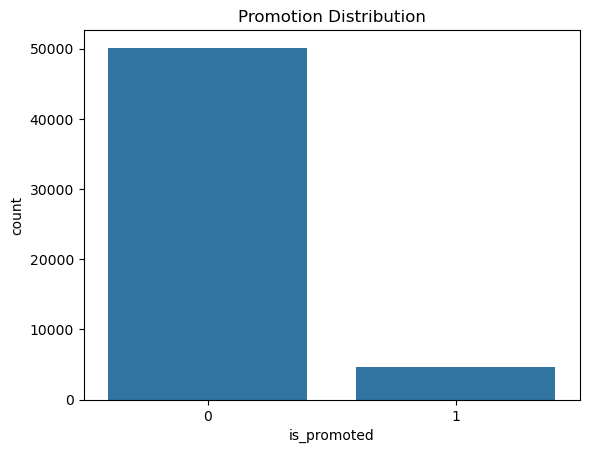

In [215]:
sns.countplot(x='is_promoted', data=data)
plt.title('Promotion Distribution')
plt.show()

In [216]:
# Most likely to be promoted among categorical columns
for col in cat_cols:
    ct = pd.crosstab(data[col], data['is_promoted'], normalize='index')
    top = ct.sort_values(by=1, ascending=False).head(1)
    
    category = top.index[0]
    value = top[1].values[0]
    
    print(f"{col} → {category} has highest promotion rate: {round(value*100,2)}%\n")

department → Technology has highest promotion rate: 10.76%

region → region_4 has highest promotion rate: 14.45%

education → Master's & above has highest promotion rate: 9.86%

gender → f has highest promotion rate: 8.99%

recruitment_channel → referred has highest promotion rate: 12.08%

no_of_trainings → 1 has highest promotion rate: 8.81%

previous_year_rating → 5.0 has highest promotion rate: 16.36%

awards_won? → 1 has highest promotion rate: 44.02%



In [217]:
# converting age into cat_col and checking the relation with target column
data['age_group'] = pd.cut(data['age'], bins=[20,30,40,50,60], 
                           labels=['20-30','30-40','40-50','50-60'])

pd.crosstab(data['age_group'], data['is_promoted'], normalize='index').round(2)

is_promoted,0,1
age_group,,
20-30,0.91,0.09
30-40,0.91,0.09
40-50,0.93,0.07
50-60,0.93,0.07


Thus employees between ages 20 to 40 are more likely to be promoted

In [218]:
data['training_score'] = pd.cut(data['avg_training_score'], bins=[10,20,30,40,50,60,70,80,90,100], 
                           labels=['10-20','20-30','30-40','40-50','50-60','60-70','70-80','80-90','90-100'])

pd.crosstab(data['training_score'], data['is_promoted'], normalize='index').round(2)

is_promoted,0,1
training_score,,
30-40,1.00,0.00
40-50,0.96,0.04
50-60,0.95,0.05
60-70,0.91,0.09
70-80,0.90,0.10
80-90,0.87,0.13
90-100,0.12,0.88


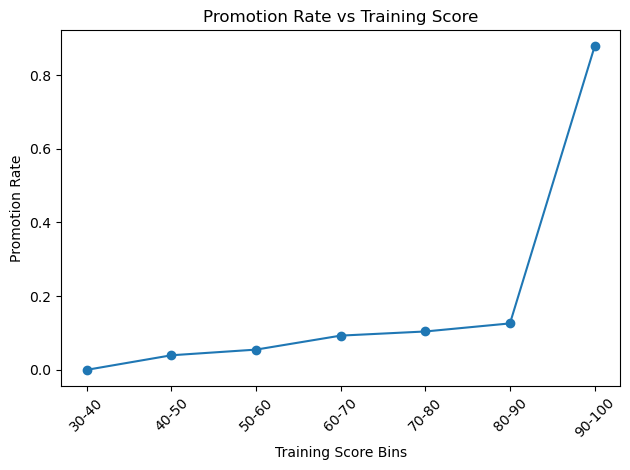

In [219]:
promo_rate = pd.crosstab(data['training_score'], data['is_promoted'], normalize='index')[1]

plt.figure()
promo_rate.plot(marker='o')
plt.title('Promotion Rate vs Training Score')
plt.xlabel('Training Score Bins')
plt.ylabel('Promotion Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

1) Age alone does not strongly influence promotion
2) Low performers rarely get promoted
3) Higher training score = higher chance of promotion

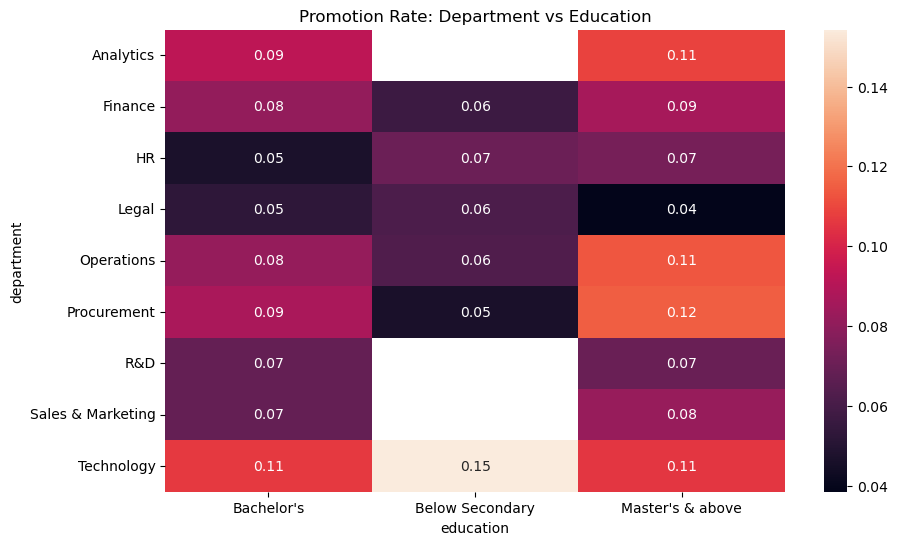

In [220]:
pivot = pd.pivot_table(data, values='is_promoted', index='department', columns='education',  aggfunc='mean')
plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt='.2f')
plt.title('Promotion Rate: Department vs Education')
plt.show()

In [221]:
grouped = data.groupby('department').mean(numeric_only=True).reset_index()
grouped['count'] = data.groupby('department').size().values

print(grouped.head())

   department  no_of_trainings        age  previous_year_rating  \
0   Analytics         1.337818  32.431241              3.247571   
1     Finance         1.304022  32.058754              3.115142   
2          HR         1.053763  34.385856              3.128619   
3       Legal         1.089509  33.832531              2.854668   
4  Operations         1.160821  36.073669              3.443955   

   length_of_service  awards_won?  avg_training_score  is_promoted  count  
0           4.932735     0.024290           84.602952     0.095665   5352  
1           4.819401     0.027603           60.222003     0.081230   2536  
2           5.683623     0.018610           50.018197     0.056245   2418  
3           4.599615     0.024062           59.868142     0.051011   1039  
4           6.416020     0.023088           60.226648     0.090148  11348  


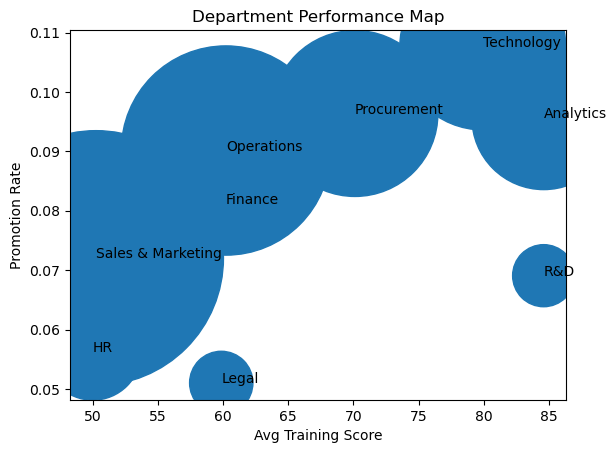

In [222]:
# department vise peformance
plt.figure()
plt.scatter(grouped['avg_training_score'], 
            grouped['is_promoted'], 
            s=grouped['count'] * 2)
for i in range(len(grouped)):
    plt.text(grouped['avg_training_score'][i], 
             grouped['is_promoted'][i], 
             grouped['department'][i])
plt.xlabel('Avg Training Score')
plt.ylabel('Promotion Rate')
plt.title('Department Performance Map')
plt.show()

X-axis: Avg Training Score → performance
Y-axis: Promotion Rate → success outcome
Bubble size: Number of employees → department size

Thus, 
1) Technology and Analytics are best peformers
2) HR, Legal are underpeforming
3) Sales & Marketing have huge workforce yet low peformance
4) R&D have good performers but not getting promoted proportionally

Most employees possess relatively similar competency levels after training.

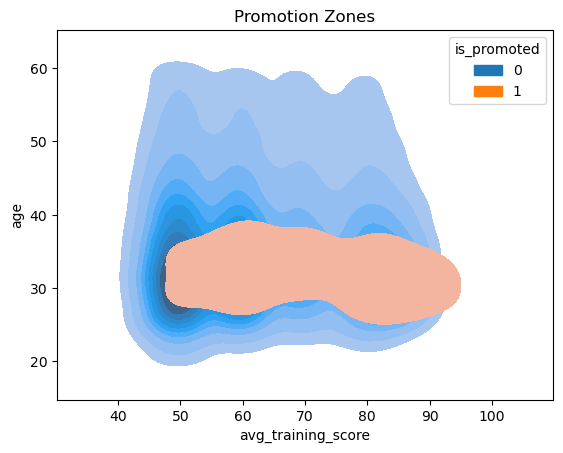

In [223]:
sns.kdeplot(data=data, x='avg_training_score', y='age', hue='is_promoted', fill=True)
plt.title('Promotion Zones')
plt.show()

1) Promotions (orange) are concentrated between ages 25 and 40
2) Most employees (blue) are clustered around a training score of 50.
3) Promotions drop off sharply after age 40, despite high training scores.

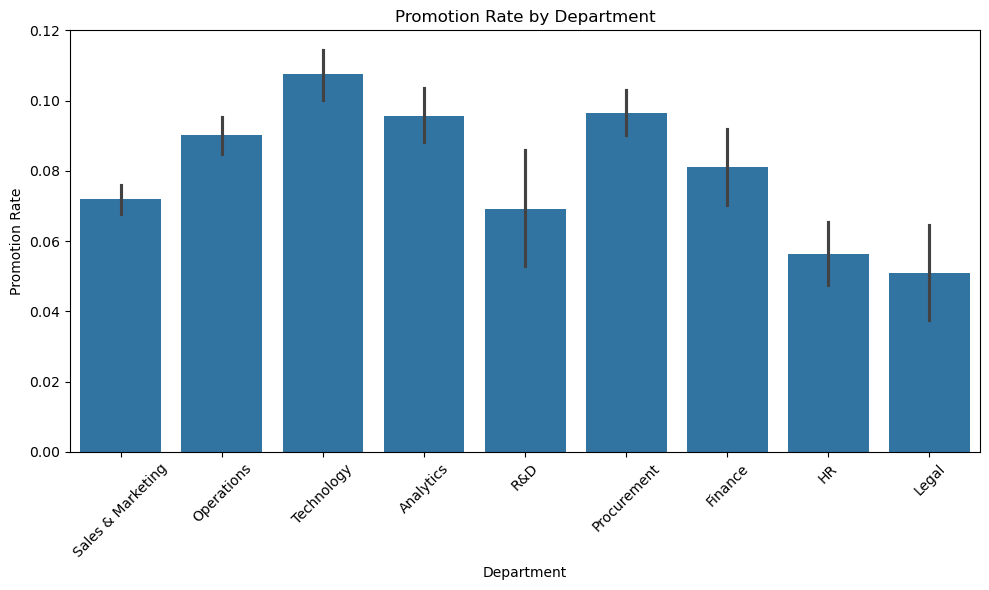

In [224]:
plt.figure(figsize=(10,6))
sns.barplot(x='department', y='is_promoted', data=data)
plt.xticks(rotation=45)
plt.title('Promotion Rate by Department')
plt.xlabel('Department')
plt.ylabel('Promotion Rate')
plt.tight_layout()
plt.show()

# Key Insights

- **Training performance is the strongest driver of promotion**  
  Employees with training scores above 80 have a significantly higher probability of being promoted.

- **Low-performing employees are rarely promoted**  
  Employees with scores below 60 show almost negligible promotion rates.

- **Age has minimal impact on promotion decisions**  
  Promotions are fairly distributed across age groups with no strong pattern.

- **Experience shows diminishing returns**  
  Promotion likelihood increases in early to mid-career stages but plateaus at higher experience levels.

- **Significant variation exists across departments**  
  Departments like Technology and Analytics have higher promotion rates, while HR and Legal lag behind.

- **Large departments tend to have lower promotion rates**  
  Departments such as Sales & Marketing have a larger workforce but comparatively lower promotion rates.

- **High performance does not always guarantee promotion**  
  Some high-scoring employees are not promoted, indicating the influence of additional factors.

- **Department plays a key role alongside performance**  
  Employees with similar performance levels may have different promotion outcomes depending on their department.

- **Mid-range performers show inconsistent promotion trends**  
  Employees in the 60–80 score range exhibit mixed promotion outcomes, suggesting variability in evaluation.

# Business Recommendations

- **Prioritize performance-driven promotion policies**  
  Strengthen systems that consistently reward employees with high training performance.

- **Investigate low-performing departments**  
  Conduct detailed reviews in departments with low promotion rates (e.g., HR, Legal) to identify structural or managerial issues.

- **Improve promotion transparency and consistency**  
  Establish clear and standardized criteria to ensure deserving employees are not overlooked.

- **Optimize training programs**  
  Focus on improving mid-range performers (score 60–80), as they represent the largest opportunity for growth.

- **Balance workforce size with promotion opportunities**  
  In large departments like Sales & Marketing, ensure fair promotion distribution to avoid employee stagnation.

- **Standardize evaluation criteria across departments**  
  Reduce inconsistencies where similar performance levels lead to different promotion outcomes.

- **Identify and address promotion bottlenecks**  
  Analyze cases where high-performing employees are not promoted and fix gaps in the evaluation process.

- **Leverage high-performing departments as benchmarks**  
  Adopt best practices from departments like Technology and Analytics to improve performance in other areas.

# Conclusion

This analysis highlights that employee promotions are primarily driven by performance, with training scores emerging as the most significant factor. Employees with higher training scores demonstrate a substantially greater likelihood of being promoted, indicating a strong performance-based promotion system.

However, promotion outcomes are not solely determined by performance. Departmental differences play a crucial role, with certain departments consistently showing higher promotion rates than others. Additionally, factors such as experience contribute to promotion likelihood only up to a certain point, after which their impact stabilizes.

The presence of high-performing employees who are not promoted suggests potential inconsistencies in evaluation criteria or decision-making processes. Furthermore, larger departments tend to have lower promotion rates, indicating possible structural or capacity-related limitations.

Overall, while the organization demonstrates a performance-oriented promotion approach, there is scope to improve transparency, consistency, and fairness across departments. Addressing these gaps can lead to a more balanced and effective employee growth strategy.

## Data Encoding

In [225]:
data = pd.read_csv(r'train.csv')

In [226]:
data.set_index('employee_id', inplace=True)

In [227]:
# defining a code to encode all the catwgorical columns in a single go

def encode_categorical_columns(df):
  encoders = {}

  for col in cat_cols:
    unique_values = df[col].unique()
    mapping = {value: i for i, value in enumerate(unique_values)} 
    encoders[col] = mapping
    df[col] = df[col].map(mapping)

  return df, encoders

In [228]:
encode_categorical_columns(data)

(             department  region  education  gender  recruitment_channel  \
 employee_id                                                               
 65438                 0       0          0       0                    0   
 65141                 1       1          1       1                    1   
 7513                  0       2          1       1                    0   
 2542                  0       3          1       1                    1   
 48945                 2       4          1       1                    1   
 ...                 ...     ...        ...     ...                  ...   
 3030                  2      13          1       1                    0   
 74592                 1      22          0       0                    1   
 13918                 3       8          1       1                    1   
 13614                 0      32          2       1                    0   
 51526                 7       1          1       1                    1   
 
          

## Train/Test Split

In [229]:
from sklearn.model_selection import train_test_split

In [230]:
y = data['is_promoted']
x = data.drop(columns='is_promoted')

In [231]:
x.head()

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score
employee_id,,,,,,,,,,,
65438,0,0,0,0,0,0,35,0,8,0,49
65141,1,1,1,1,1,0,30,0,4,0,60
7513,0,2,1,1,0,0,34,1,7,0,50
2542,0,3,1,1,1,1,39,2,10,0,50
48945,2,4,1,1,1,0,45,1,2,0,73


In [232]:
y

employee_id
65438    0
65141    0
7513     0
2542     0
48945    0
        ..
3030     0
74592    0
13918    0
13614    0
51526    0
Name: is_promoted, Length: 54808, dtype: int64

In [233]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [234]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(43846, 11)
(10962, 11)
(43846,)
(10962,)


##  Model Training

In [255]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [236]:
models = []
accuracy = []
precision = []
recall = []
f1 = []

def model_val(model, xtrain, ytrain, xtest, ytest):
    
    mod = model
    mod.fit(xtrain, ytrain)
    pred = mod.predict(xtest)
    
    # Store results
    models.append(type(model).__name__)
    accuracy.append(accuracy_score(ytest, pred))
    precision.append(precision_score(ytest, pred))
    recall.append(recall_score(ytest, pred))
    f1.append(f1_score(ytest, pred))
    
    # Create scorecard
    scorecard = pd.DataFrame({
        'Model': models,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })
    
    return scorecard

In [237]:
scorecard = model_val(LogisticRegression(max_iter=1000), x_train, y_train, x_test, y_test)
scorecard

,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.913428,0.689655,0.0611,0.112254


In [239]:
scorecard = model_val(DecisionTreeClassifier(max_depth=5), x_train, y_train, x_test, y_test)
scorecard

,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.913428,0.689655,0.061100,0.112254
1,DecisionTreeClassifier,0.927112,0.914027,0.205703,0.335827


In [240]:
scorecard = model_val(RandomForestClassifier(), x_train, y_train, x_test, y_test)
scorecard

,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.913428,0.689655,0.061100,0.112254
1,DecisionTreeClassifier,0.927112,0.914027,0.205703,0.335827
2,RandomForestClassifier,0.932494,0.855882,0.296334,0.440242


In [245]:
scorecard = model_val(XGBClassifier(n_estimators=200,learning_rate=0.1, max_depth=5, random_state=42,
                                     use_label_encoder=False,eval_metric='logloss'), x_train, y_train, x_test, y_test)
scorecard

,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.913428,0.689655,0.061100,0.112254
1,DecisionTreeClassifier,0.927112,0.914027,0.205703,0.335827
2,RandomForestClassifier,0.932494,0.855882,0.296334,0.440242
3,XGBClassifier,0.940248,0.960563,0.347251,0.510097


In [247]:
scorecard = model_val(RandomForestClassifier( n_estimators=200, max_depth=8, min_samples_split=5,
                                              class_weight='balanced', random_state=42), x_train, y_train, x_test, y_test)
scorecard

,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.913428,0.689655,0.061100,0.112254
1,DecisionTreeClassifier,0.927112,0.914027,0.205703,0.335827
2,RandomForestClassifier,0.932494,0.855882,0.296334,0.440242
3,XGBClassifier,0.940248,0.960563,0.347251,0.510097
4,RandomForestClassifier,0.826400,0.269865,0.549898,0.362052


### Using XGBoost as Final Model

In [249]:
scale = (y_train == 0).sum() / (y_train == 1).sum()

final_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss')

final_model.fit(x_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [250]:
y_pred = final_model.predict(x_test)
y_proba = final_model.predict_proba(x_test)[:,1]

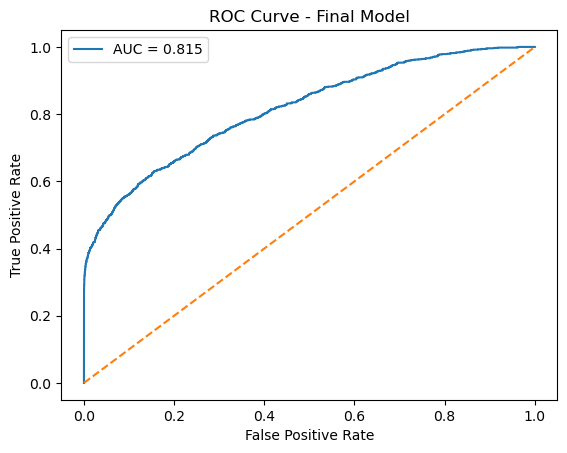

In [252]:
# roc curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Final Model')
plt.legend()

plt.show()

In [254]:
# AUC metrics
roc_auc_score(y_test, y_proba)

0.8153177536335399

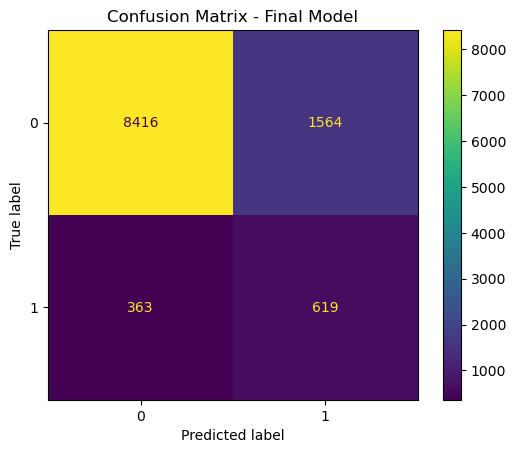

In [256]:
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot()
plt.title('Confusion Matrix - Final Model')
plt.show()

In [257]:
# classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.84      0.90      9980
           1       0.28      0.63      0.39       982

    accuracy                           0.82     10962
   macro avg       0.62      0.74      0.64     10962
weighted avg       0.90      0.82      0.85     10962



# Final Model

An optimized XGBoost model was selected as the final model due to its superior performance in balancing precision and recall.

The model was tuned using hyperparameters such as learning rate, tree depth, and class imbalance handling.

### Model Evaluation

- ROC-AUC score indicates strong classification performance  
- The ROC curve shows good separation between promoted and non-promoted employees  
- Confusion matrix highlights the model’s ability to correctly identify promotion cases  

Overall, the model effectively captures the key drivers of promotion and provides reliable predictions.

## Using test data to check model accuracy

In [259]:
test = pd.read_csv('test.csv')

In [260]:
test.set_index('employee_id', inplace=True)

In [261]:
# encoding
encode_categorical_columns(test)

(             department  region  education  gender  recruitment_channel  \
 employee_id                                                               
 8724                  0       0          0       0                    0   
 74430                 1       1          0       1                    1   
 72255                 2       2          0       0                    1   
 38562                 3       3          0       1                    1   
 64486                 4       4          0       0                    0   
 ...                 ...     ...        ...     ...                  ...   
 53478                 7       3          3       0                    0   
 25600                 0      24          0       0                    0   
 45409                 1       7          0       1                    0   
 1186                  3      18          0       0                    0   
 5973                  0       8          1       0                    1   
 
          

In [263]:
test = test.reindex(columns=x_train.columns, fill_value=0)

In [265]:
test_pred = final_model.predict(test)
test_proba = final_model.predict_proba(test)[:,1]

In [266]:
test['is_promoted_pred'] = test_pred
test['promotion_probability'] = test_proba

In [268]:
test.reset_index(inplace=True)

test[['employee_id', 'is_promoted_pred']].to_csv('final.csv', index=False)

## Test Data Prediction

The final trained model was applied to unseen test data after performing the same preprocessing steps used during training.

Predictions were generated along with probability scores, and the results were exported for further use. This step simulates real-world deployment where the model is used to make decisions on new data.